In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("./data/ecommerce_sales.csv")

df["order_date"] = pd.to_datetime(df["order_date"])

df.head()

,order_id,customer_id,product_id,category,price,discount,quantity,payment_method,order_date,delivery_time_days,region,returned,total_amount,shipping_cost,profit_margin,customer_age,customer_gender
0,O100000,C17270,P234890,Home,164.08,0.15,1,Credit Card,2023-12-23,4,West,No,139.47,7.88,31.17,60,Female
1,O100001,C17603,P228204,Grocery,24.73,0.00,1,Credit Card,2025-04-03,6,South,No,24.73,4.60,-2.62,37,Male
2,O100002,C10860,P213892,Electronics,175.58,0.05,1,Credit Card,2024-10-08,4,North,No,166.80,6.58,13.44,34,Male
3,O100003,C15390,P208689,Electronics,63.67,0.00,1,UPI,2024-09-14,6,South,No,63.67,5.50,2.14,21,Female
4,O100004,C15226,P228063,Home,16.33,0.15,1,COD,2024-12-21,6,East,No,13.88,2.74,1.15,39,Male


In [6]:
reference_date = df["order_date"].max()

In [7]:
recency = df.groupby("customer_id")["order_date"].max()

recency = (reference_date - recency).dt.days

In [8]:
frequency = df.groupby("customer_id")["order_id"].nunique()

In [9]:
monetary = df.groupby("customer_id")["total_amount"].sum()

In [10]:
rfm = pd.DataFrame({
    "Recency": recency,
    "Frequency": frequency,
    "Monetary": monetary
})

rfm.head()

,Recency,Frequency,Monetary
customer_id,,,
C10000,4,2,210.58
C10001,193,5,3246.02
C10002,400,5,216.85
C10003,71,3,154.30
C10004,599,3,716.99


In [11]:
rfm = rfm.dropna()

In [12]:
rfm = rfm[
    (rfm["Frequency"] > 0) &
    (rfm["Monetary"] > 0)
]

In [13]:
scaler = StandardScaler()

rfm_scaled = scaler.fit_transform(rfm)


In [14]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

In [15]:
print(rfm.head())

             Recency  Frequency  Monetary  Cluster
customer_id                                       
C10000             4          2    210.58        3
C10001           193          5   3246.02        4
C10002           400          5    216.85        2
C10003            71          3    154.30        3
C10004           599          3    716.99        0


In [16]:
cluster_summary = rfm.groupby("Cluster")[
    ["Recency", "Frequency", "Monetary"]
].mean()

print(cluster_summary)

            Recency  Frequency     Monetary
Cluster                                    
0        513.264386   1.945568   312.746423
1         81.418538   6.708552   954.377587
2        269.756168   3.276535   453.670935
3         76.309417   3.560193   441.290262
4        108.375238   6.049524  3041.211238


In [17]:
pca = PCA(n_components=2)

rfm_pca = pca.fit_transform(rfm_scaled)

In [18]:
rfm["PCA1"] = rfm_pca[:, 0]
rfm["PCA2"] = rfm_pca[:, 1]

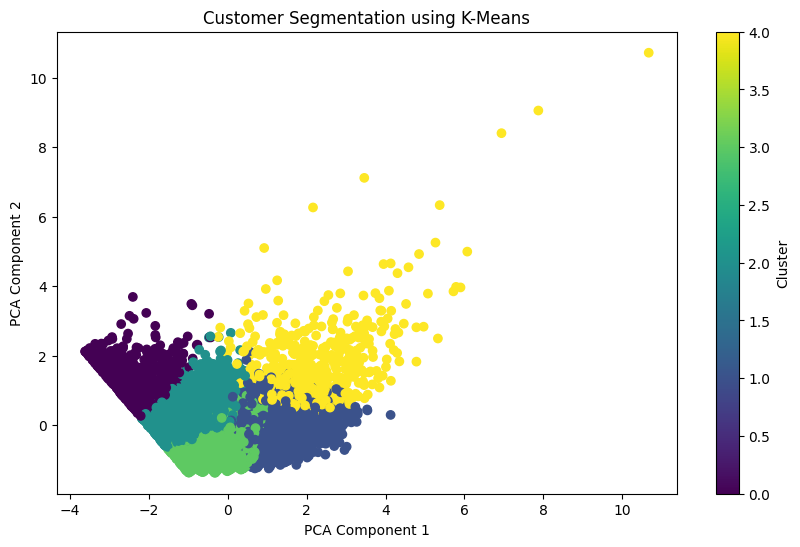

In [19]:
plt.figure(figsize=(10, 6))

plt.scatter(
    rfm["PCA1"],
    rfm["PCA2"],
    c=rfm["Cluster"],
    cmap="viridis"
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Customer Segmentation using K-Means")
plt.colorbar(label="Cluster")

plt.show()

In [20]:
inertia = []

for k in range(2, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(rfm_scaled)

    inertia.append(model.inertia_)

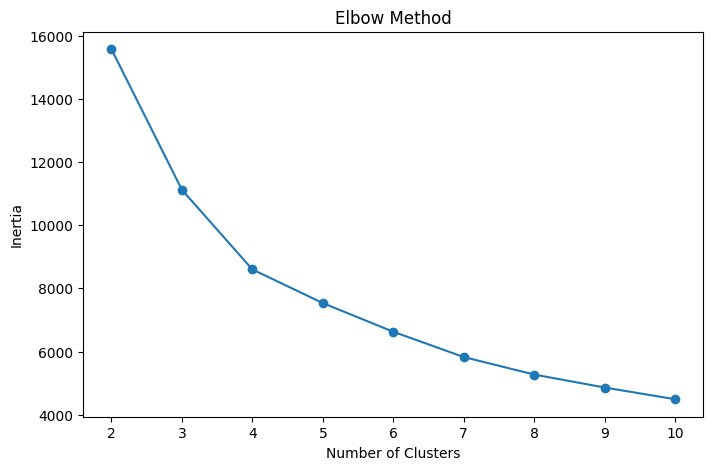

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertia, marker="o")

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [24]:
rfm.to_csv(
    "./data/customer_segments.csv",
    index=True
)


print("Customer segmentation saved successfully!")

Customer segmentation saved successfully!
